# UCI SECOM 반도체 제조 품질분석 — 실행 증거 Notebook

이 Notebook은 공개·익명화된 [UCI SECOM](https://archive.ics.uci.edu/dataset/179/secom) 원본을 다시 읽고, 고정된 train/test split에서 Dummy·Logistic Regression·Random Forest를 재학습해 저장된 결과와 일치하는지 확인한다.

목적은 높은 수치를 과장하는 것이 아니라 **데이터 품질, leakage 통제, FAIL Recall–Precision trade-off, False Negative, 시간 일반화 한계**를 채용담당자가 빠르게 검토할 수 있게 하는 것이다. 생산 적용이나 공정 원인 규명을 주장하지 않는다.

In [1]:
from pathlib import Path
import json
import platform
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.base import clone
from sklearn.model_selection import train_test_split

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "secom_analysis.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current directory")

ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))

import secom_analysis as analysis

print(f"Python: {platform.python_version()}")
print("Project-local analysis environment loaded.")
print("Project root located successfully.")

Python: 3.12.13
Project-local analysis environment loaded.
Project root located successfully.


## 1. 공식 원본과 데이터 품질

In [2]:
X, y, metadata = analysis.load_secom(ROOT / "data" / "raw")
dataset_summary, feature_quality, row_quality = analysis.audit_dataset(X, y, metadata)

audit_view = pd.DataFrame({
    "item": [
        "rows", "actual input features", "PASS", "FAIL", "FAIL rate",
        "missing cells", "missing cell rate", "features with missing",
        "observed constant features", "exact duplicate feature rows",
    ],
    "value": [
        dataset_summary["rows"], dataset_summary["input_features_actual"],
        dataset_summary["pass_count"], dataset_summary["fail_count"],
        f"{dataset_summary['fail_pct']:.2%}", dataset_summary["missing_cells"],
        f"{dataset_summary['missing_cell_pct']:.2%}",
        dataset_summary["features_with_missing"],
        dataset_summary["observed_constant_features_full_data"],
        dataset_summary["duplicate_feature_rows"],
    ],
})
display(audit_view)

assert X.shape == (1567, 590)
assert y.value_counts().sort_index().to_dict() == {0: 1463, 1: 104}
assert int(X.isna().sum().sum()) == 41_951
assert dataset_summary["observed_constant_features_full_data"] == 116

,item,value
0,rows,1567
1,actual input features,590
2,PASS,1463
3,FAIL,104
4,FAIL rate,6.64%
5,missing cells,41951
6,missing cell rate,4.54%
7,features with missing,538
8,observed constant features,116
9,exact duplicate feature rows,0


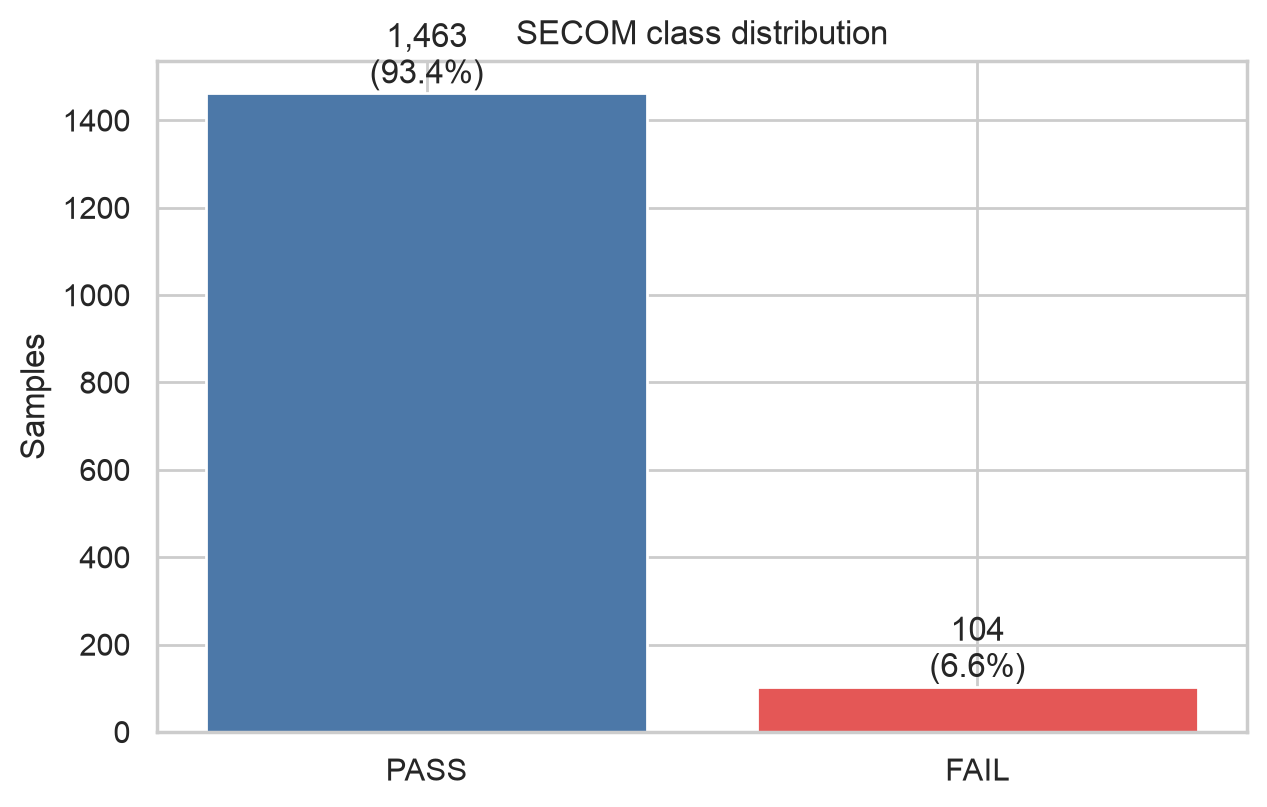

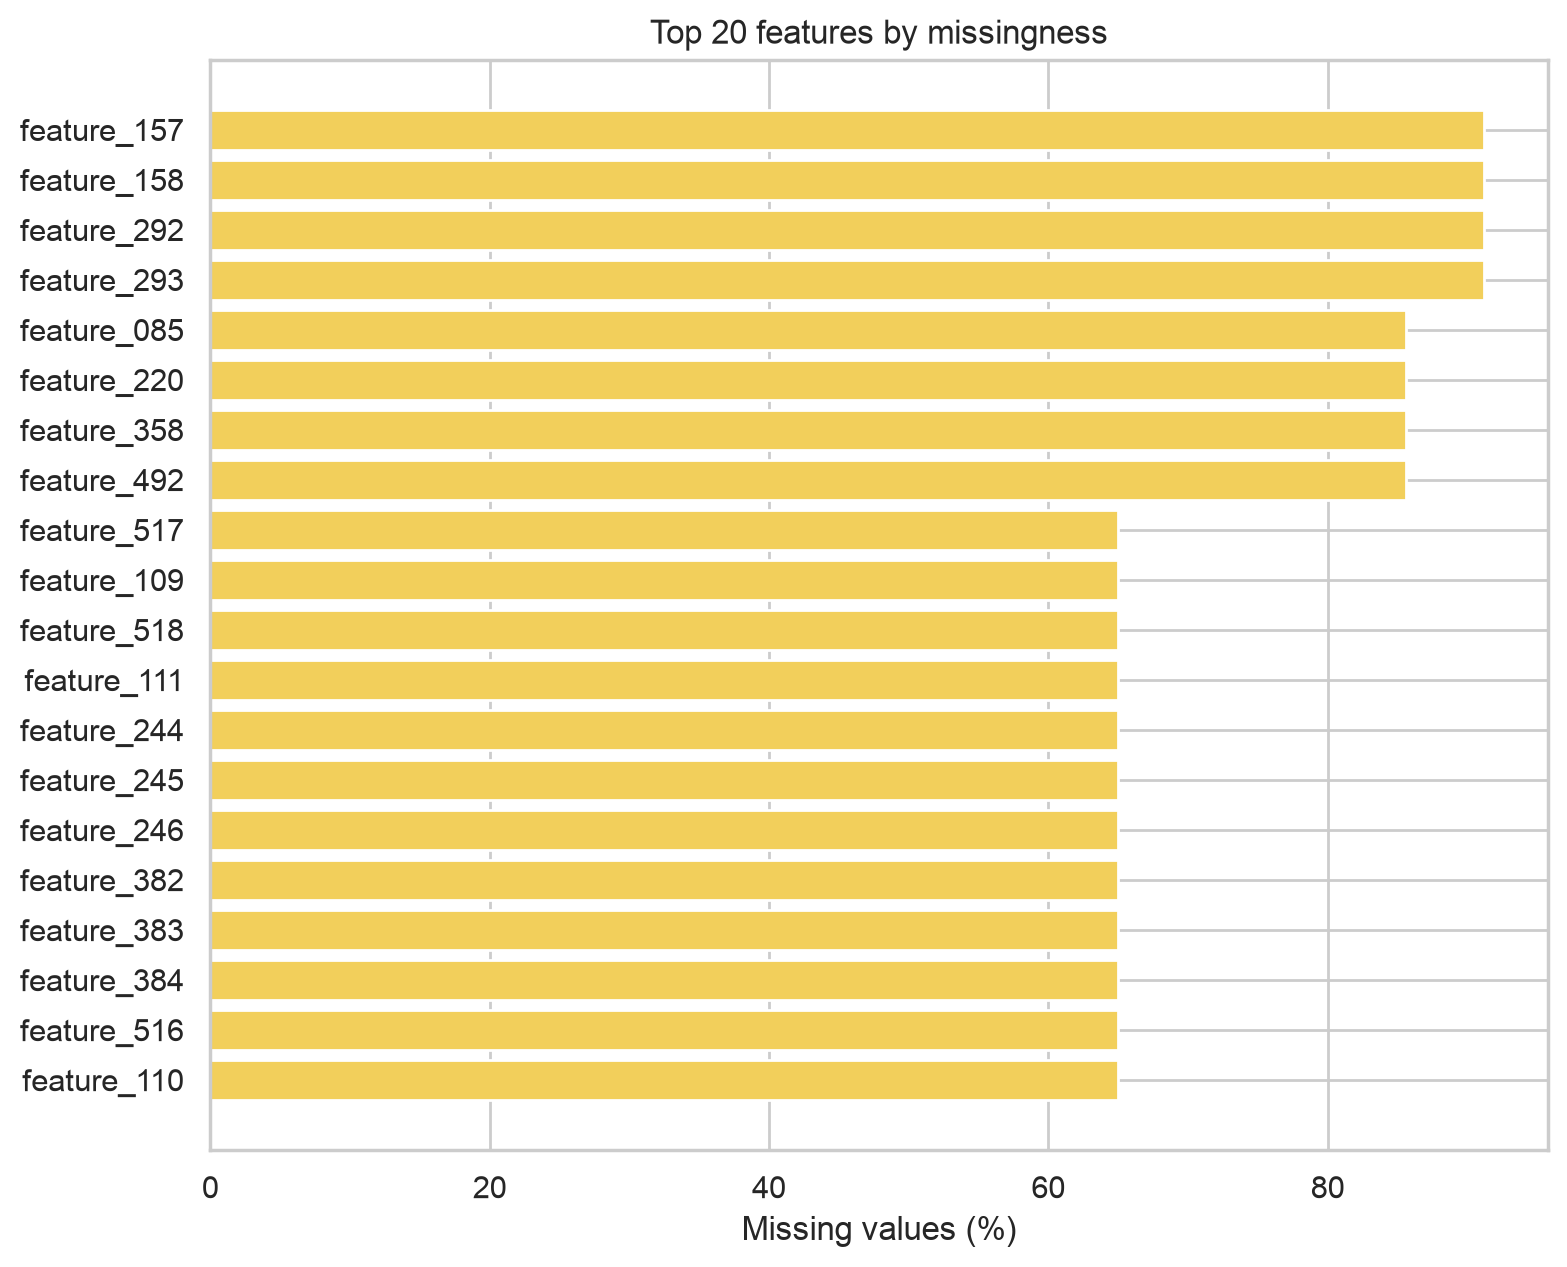

In [3]:
display(Image(filename=str(ROOT / "figures" / "01_class_distribution.png")))
display(Image(filename=str(ROOT / "figures" / "02_missingness_top20.png")))

UCI 웹 메타데이터는 591 features라고 설명하지만, 공식 `secom.data`의 모든 행에는 실제 값이 590개다. 분석은 임의의 변수를 추가하지 않고 원본 파일 구조를 따른다. 라벨은 UCI `-1=PASS`, `1=FAIL`을 코드 내부 `0=PASS`, `1=FAIL`로 매핑한다.

## 2. Leakage 방지 설계와 고정 split

In [4]:
split_summary = json.loads((ROOT / "results" / "metadata" / "split_summary.json").read_text())
display(pd.DataFrame([split_summary]).T.rename(columns={0: "recorded value"}))

models = analysis.make_models(analysis.SEED)
pipeline_steps = {
    name: " → ".join(model.named_steps.keys())
    for name, model in models.items()
}
display(pd.Series(pipeline_steps, name="train-fold-only pipeline").to_frame())

assert split_summary["train_rows"] == 1253
assert split_summary["test_rows"] == 314
assert split_summary["train_fail"] == 83
assert split_summary["test_fail"] == 21
assert split_summary["timestamp_used_as_model_feature"] is False

,recorded value
method,stratified random holdout
random_seed,42
test_size_requested,0.2
train_rows,1253
test_rows,314
train_pass,1170
train_fail,83
test_pass,293
test_fail,21
shared_timestamp_groups_across_train_test,11


,train-fold-only pipeline
dummy_prior,imputer → drop_constant → classifier
logistic_balanced,imputer → drop_constant → scaler → classifier
random_forest_balanced,imputer → drop_constant → classifier


결측 대치, 분산 0 변수 제거, Logistic 표준화는 모두 `sklearn Pipeline` 내부에서 각 학습 fold에만 fit된다. timestamp는 모델 입력에서 제외했다. 동일 timestamp 11개 그룹(22행)이 무작위 train/test 양쪽에 걸쳐 있어 미지의 batch proxy 가능성은 한계로 남긴다.

## 3. Baseline 재학습과 잠금 테스트 지표 재계산

In [5]:
train_indices, test_indices = train_test_split(
    X.index,
    test_size=analysis.TEST_SIZE,
    random_state=analysis.SEED,
    stratify=y,
)
X_train, X_test = X.loc[train_indices], X.loc[test_indices]
y_train, y_test = y.loc[train_indices], y.loc[test_indices]

threshold_record = json.loads(
    (ROOT / "results" / "metadata" / "threshold_selection.json").read_text()
)
quality_threshold = threshold_record["selected_threshold"]
selected_model = threshold_record["selected_model"]

fitted = {}
evaluation_rows = []
for model_name, model in models.items():
    estimator = clone(model).fit(X_train, y_train)
    fitted[model_name] = estimator
    score = analysis.positive_scores(estimator, X_test)
    evaluation_rows.append({
        "evaluation": model_name,
        "model": model_name,
        **analysis.binary_metrics(y_test, score, threshold=0.5),
    })

selected_score = analysis.positive_scores(fitted[selected_model], X_test)
evaluation_rows.append({
    "evaluation": f"{selected_model}_quality_threshold",
    "model": selected_model,
    **analysis.binary_metrics(y_test, selected_score, threshold=quality_threshold),
})

recomputed = pd.DataFrame(evaluation_rows)
saved = pd.read_csv(ROOT / "results" / "tables" / "test_metrics.csv")

for row in recomputed.to_dict("records"):
    expected = saved.loc[saved["evaluation"] == row["evaluation"]].iloc[0]
    for key in ["true_negative", "false_positive", "false_negative", "true_positive"]:
        assert int(row[key]) == int(expected[key])
    for key in [
        "fail_precision", "fail_recall", "fail_f1", "balanced_accuracy",
        "roc_auc", "average_precision", "pr_auc_trapezoid",
    ]:
        assert np.isclose(row[key], expected[key], atol=1e-12)

display(recomputed[[
    "evaluation", "threshold", "fail_precision", "fail_recall", "fail_f1",
    "balanced_accuracy", "roc_auc", "average_precision", "pr_auc_trapezoid",
    "true_negative", "false_positive", "false_negative", "true_positive",
]].round(4))
print("Saved metrics and notebook recomputation match.")

,evaluation,threshold,fail_precision,fail_recall,fail_f1,balanced_accuracy,roc_auc,average_precision,pr_auc_trapezoid,true_negative,false_positive,false_negative,true_positive
0,dummy_prior,0.5000,0.0000,0.0000,0.0000,0.5000,0.5000,0.0669,0.5334,293,0,21,0
1,logistic_balanced,0.5000,0.1538,0.2857,0.2000,0.5865,0.6468,0.1218,0.1081,260,33,15,6
2,random_forest_balanced,0.5000,0.0000,0.0000,0.0000,0.5000,0.7591,0.2287,0.2073,293,0,21,0
3,random_forest_balanced_quality_threshold,0.0609,0.1049,0.8095,0.1858,0.6573,0.7591,0.2287,0.2073,148,145,4,17


Saved metrics and notebook recomputation match.


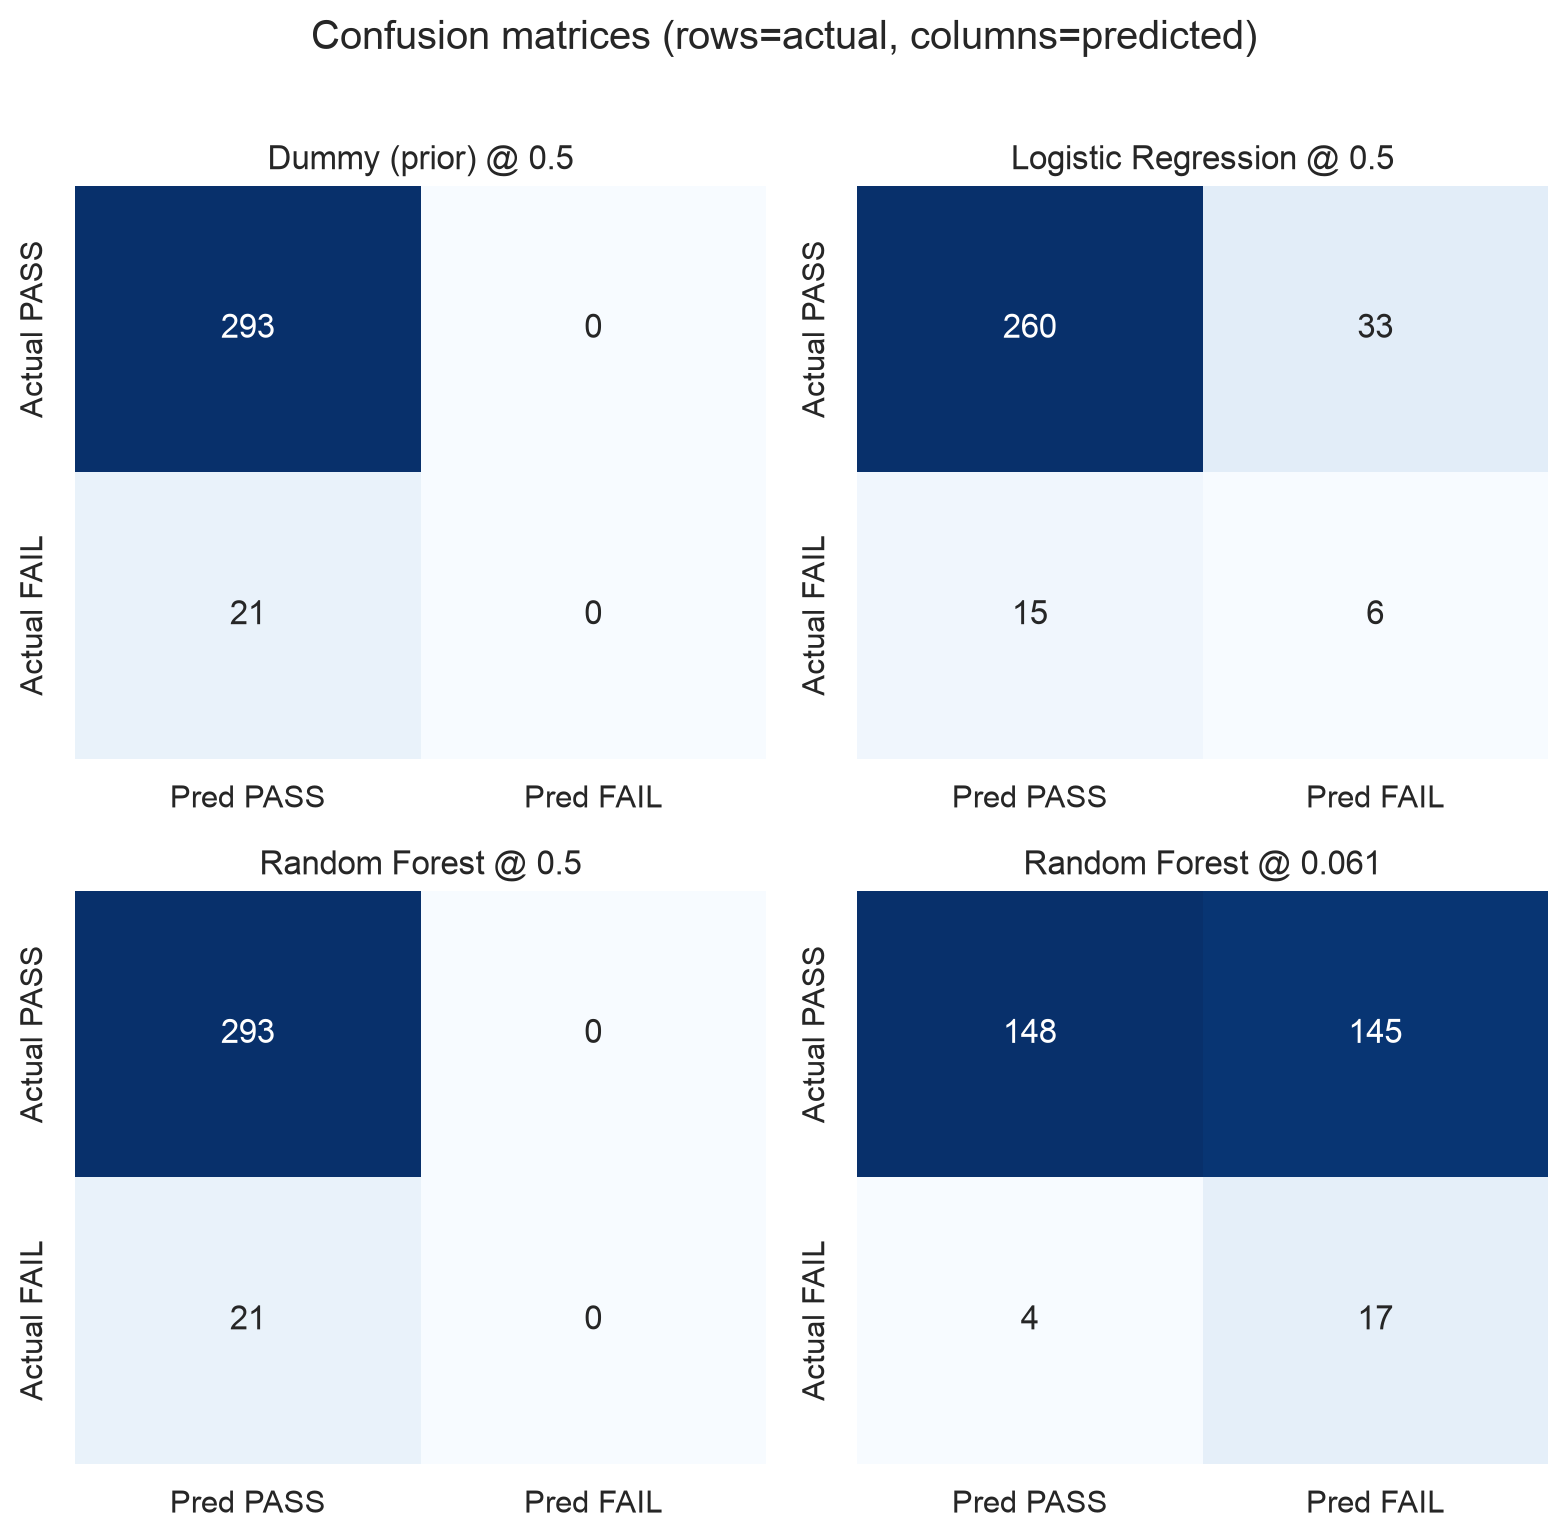

In [6]:
display(Image(filename=str(ROOT / "figures" / "05_confusion_matrices.png")))

Random Forest @ 0.5는 Accuracy 93.31%지만 실제 FAIL 21건을 전부 놓쳤다. train-only OOF에서 정한 후보 임계값 `0.060939`에서는 17/21을 찾아 Recall 80.95%가 되었지만, PASS 145건을 오탐해 Precision은 10.49%였다. 이 값은 보정된 불량확률이나 운영 최적점이 아니라 FN 감소와 추가검사 부담의 **분석 가정**이다.

## 4. False Negative 4건

,sample_id,timestamp,missing_count,random_forest_balanced_score,selected_threshold,score_minus_threshold,top_robust_deviations
0,sample_0231,2008-08-17 12:16:00,24,0.057080,0.060939,-0.003859,feature_468:2.82 IQR; feature_562:2.71 IQR; fe...
1,sample_0154,2008-08-07 11:40:00,28,0.050705,0.060939,-0.010234,feature_040:11.60 IQR; feature_031:7.63 IQR; f...
2,sample_0795,2008-09-11 22:07:00,28,0.049960,0.060939,-0.010979,feature_471:5.72 IQR; feature_199:5.64 IQR; fe...
3,sample_1189,2008-09-30 02:44:00,12,0.040310,0.060939,-0.020629,feature_569:3.56 IQR; feature_423:3.45 IQR; fe...


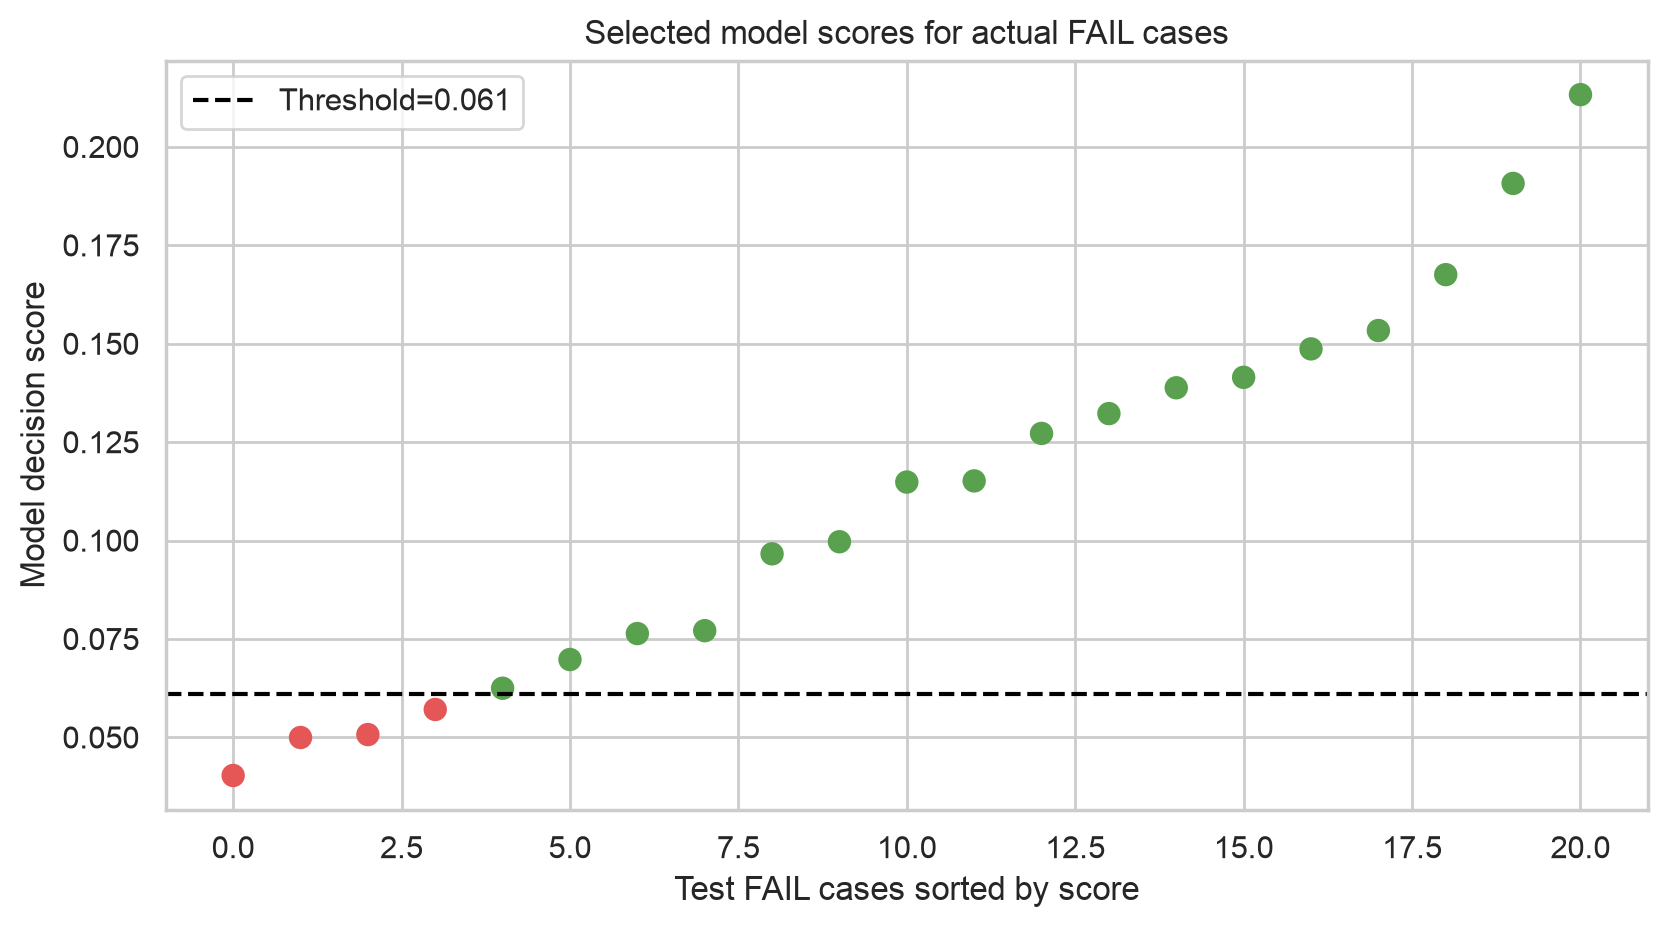

In [7]:
false_negatives = pd.read_csv(ROOT / "results" / "tables" / "false_negatives.csv")
display(false_negatives[[
    "sample_id", "timestamp", "missing_count",
    "random_forest_balanced_score", "selected_threshold",
    "score_minus_threshold", "top_robust_deviations",
]])

assert set(false_negatives["sample_id"]) == {
    "sample_0154", "sample_0231", "sample_0795", "sample_1189"
}
assert (false_negatives["random_forest_balanced_score"] < quality_threshold).all()

display(Image(filename=str(ROOT / "figures" / "09_false_negative_scores.png")))

테스트 FAIL은 21건뿐이므로 한 건이 Recall을 4.76%p 바꾼다. FN 4건의 패턴은 후속 가설 생성용이며, 이 오류를 보고 같은 test로 재학습하거나 임계값을 바꾸지 않았다.

## 5. 익명 변수 후보 — 원인 아님

,feature,logistic_top20_frequency,rf_top20_frequency,mean_absolute_coefficient,mean_ap_drop,meets_both_methods_60pct_rule
0,feature_059,1.0000,0.6,1.3094,0.0102,True
1,feature_205,0.7333,0.4,0.7903,0.0053,False
2,feature_132,0.8667,0.2,0.9573,0.0017,False
3,feature_216,0.9333,0.0,0.9883,-0.0002,False
4,feature_103,0.2000,0.6,0.3477,0.0089,False
5,feature_033,0.0000,0.8,0.1343,0.0134,False
6,feature_031,0.0000,0.6,0.2467,0.0042,False
7,feature_056,0.6000,0.0,0.7875,-0.0017,False
8,feature_078,0.5333,0.2,0.7300,0.0001,False
9,feature_040,0.4667,0.2,0.6121,0.0014,False


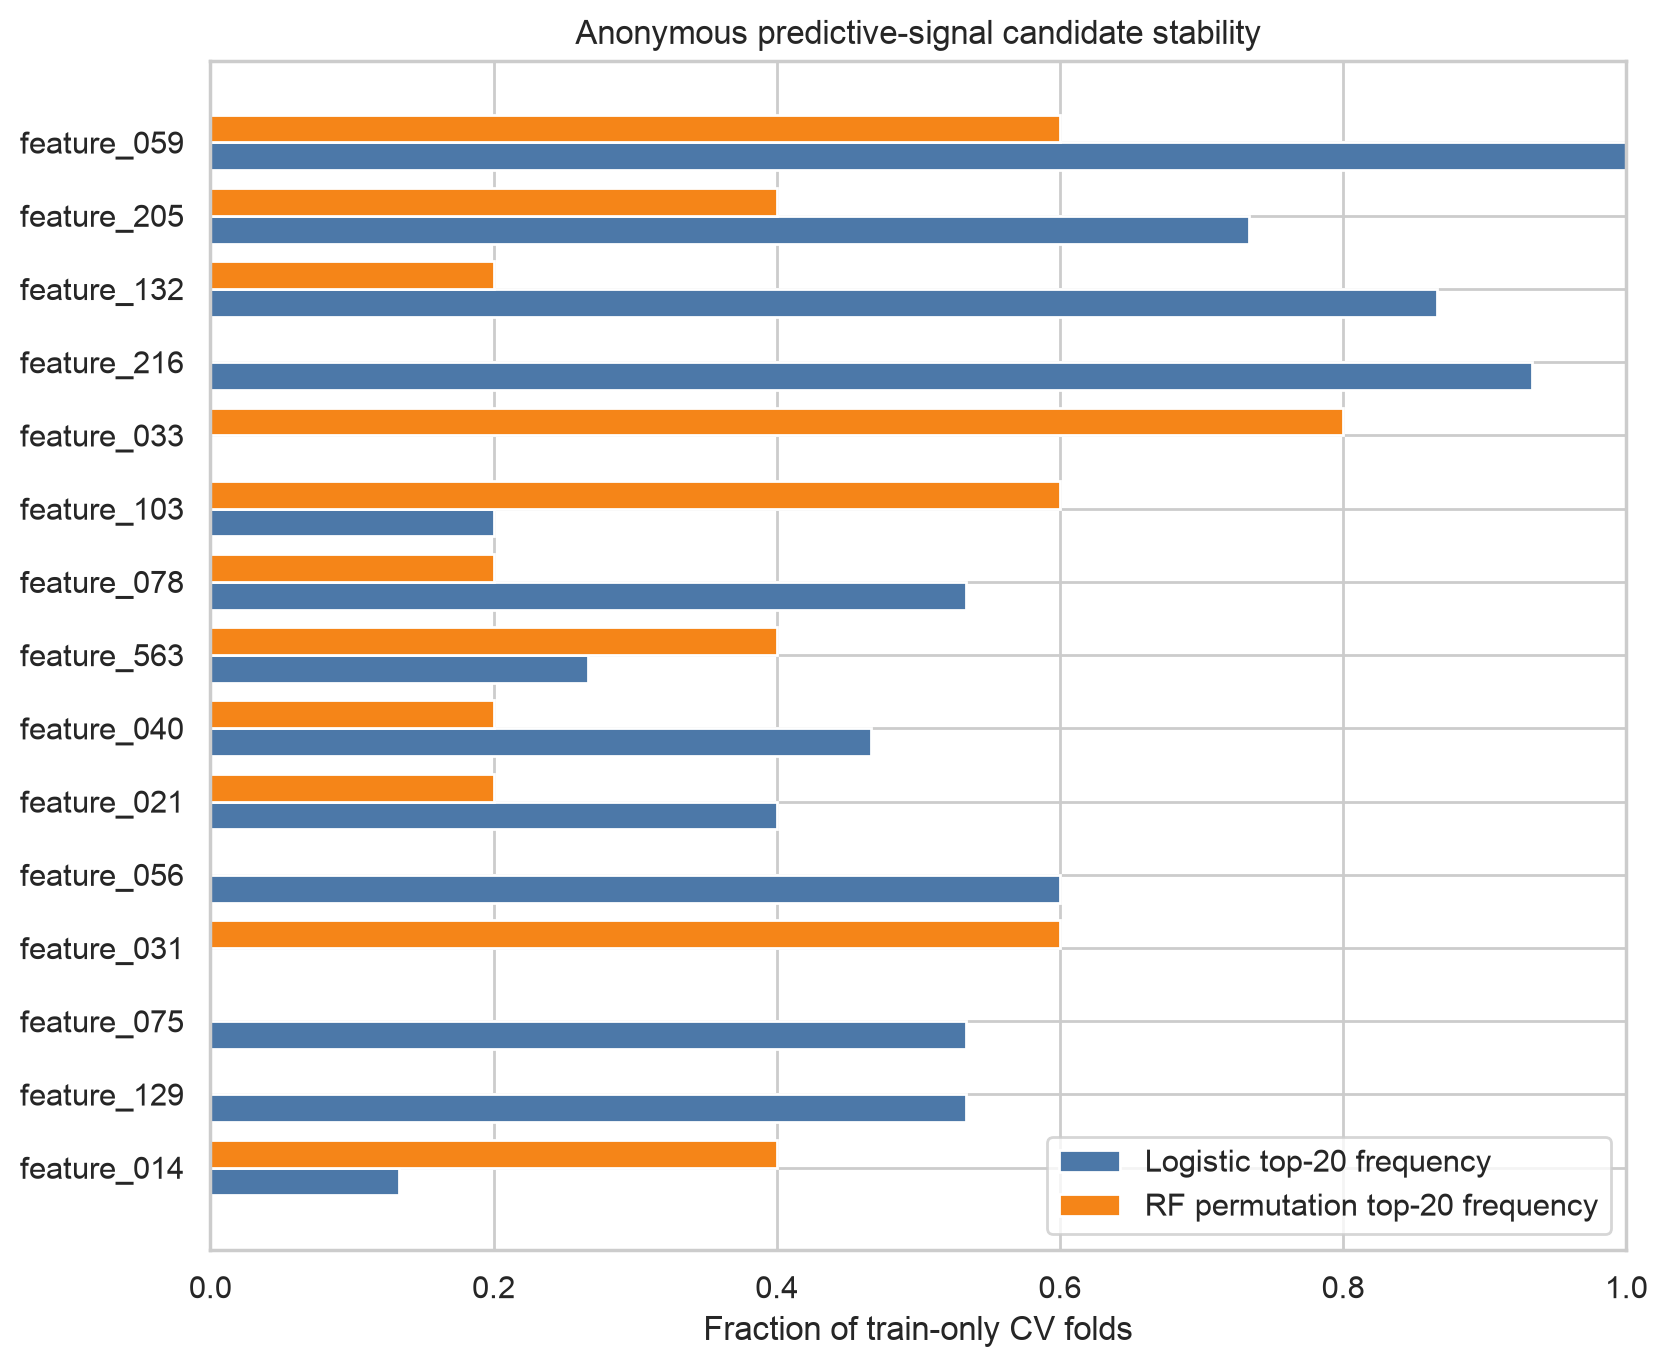

In [8]:
candidates = pd.read_csv(ROOT / "results" / "tables" / "feature_candidates.csv")
candidate_view = candidates[[
    "feature", "logistic_top20_frequency", "rf_top20_frequency",
    "mean_absolute_coefficient", "mean_ap_drop",
    "meets_both_methods_60pct_rule",
]].head(10)
display(candidate_view.round(4))

both_methods = candidates.loc[
    candidates["meets_both_methods_60pct_rule"], "feature"
].tolist()
assert both_methods == ["feature_059"]

display(Image(filename=str(ROOT / "figures" / "08_feature_candidate_stability.png")))

`feature_059`는 Logistic top-20 15/15, RF permutation top-20 3/5로 두 방법의 60% 반복 기준을 동시에 만족했다. 그러나 변수 의미·단위가 익명화되어 있으므로 특정 센서·온도·압력·식각 조건·불량 원인으로 해석할 수 없다.

## 6. 시간순 민감도 — 일반화 경고

In [9]:
temporal = json.loads(
    (ROOT / "results" / "metadata" / "temporal_sensitivity.json").read_text()
)
temporal_metrics = temporal["metrics_at_train_only_quality_threshold"]
display(pd.DataFrame([temporal_metrics]).round(4))

assert temporal["train_only_threshold_selection"]["test_data_used_to_select_threshold"] is False
assert temporal_metrics["true_positive"] == 8
assert temporal_metrics["false_negative"] == 9
assert np.isclose(temporal_metrics["fail_recall"], 8 / 17)
assert np.isclose(temporal_metrics["fail_precision"], 8 / 174)

,threshold,accuracy,balanced_accuracy,fail_precision,fail_recall,fail_f1,roc_auc,average_precision,pr_auc_trapezoid,fail_prevalence,true_negative,false_positive,false_negative,true_positive,fail_recall_wilson_low,fail_recall_wilson_high,fail_precision_wilson_low,fail_precision_wilson_high
0,0.0649,0.4427,0.4558,0.046,0.4706,0.0838,0.5144,0.0922,0.0769,0.0541,131,166,9,8,0.2616,0.6904,0.0235,0.0881


시간순 학습 데이터에서만 정한 후보 임계값 `0.064911`을 이후 기간에 적용했을 때 Recall 47.06%, Precision 4.60%, ROC-AUC 0.514, AP 0.092로 약화됐다. 모델 family는 1차 무작위 분석에서 이미 선택됐으므로 완전 독립 prospective 검증은 아니지만, 시간 일반화 위험을 숨기지 않는 민감도 증거다.

## 7. 결론과 AI 역할 경계

- 공개 익명 데이터에서 일부 FAIL score 분리 가능성은 보였으나 높은 오탐, 작은 FAIL 표본, 시간 성능 저하, batch 정보 부재로 현장 적용 근거는 부족하다.
- AI는 코드·방법론 검토와 문서 초안을 보조했다. 데이터 수·지표·혼동행렬·그래프는 Python 실행값만 사용했다.
- Gemma는 설치하거나 호출하지 않았다. 선택적 사용 시에도 가설·코드 리뷰·반론 생성에만 한정한다.
- 없는 반도체 실무 경험, SK하이닉스 공정 분석, 수율 개선, 원인 규명은 주장하지 않는다.

상세 내용은 [README](../README.md), [Quality Report](../reports/quality_report.md), [AI 사용 기록](../docs/AI_USAGE.md), [검증 로그](../docs/VALIDATION_LOG.md)에서 확인할 수 있다.